# **Mineral Prospectivity Project**
## 03 feature engineering

goals:\
-create spatial grid\
-sample data into grid

# Part 1. import packages and specify grid details

a. grid information:\
-1 km x 1 km resolution\
-extent: state of Idaho

In [119]:
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Point
from shapely.geometry import box

data_path = "/Users/adbyerly/prospectivity_model/data/processed/"

aoi = gpd.read_file('/Users/adbyerly/prospectivity_model/data/raw/maps/idaho_outline.gpkg')
print(aoi.crs)
# print(aoi.geometry.iloc[0])
# print(aoi.total_bounds)

EPSG:4269


# Part 2. create buffer for mines

/var/folders/5k/44z6_qv57sz8v3pzftxvfn4m0000gn/T/ipykernel_22516/2928576375.py:7: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  gold_buffered_union = gold_buffered.unary_union # preserve overlapping buffer polygons


<Axes: >

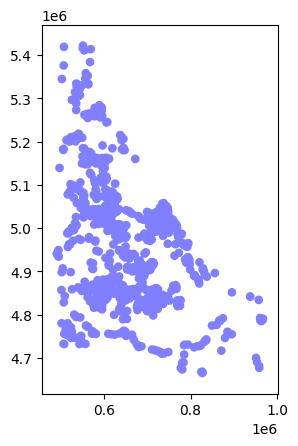

In [120]:
# create visual buffer polygons around known mines
gold_buffered = gpd.read_file(data_path + "mines_gdf_processed_producer.geojson")
# print(gold.head())

buffer = 10000  # set buffer radius to 10 km
gold_buffered['geometry'] = gold_buffered.buffer(buffer)  # set geometry column to polygons of all points within radius using GeoPandas ".buffer"
gold_buffered_union = gold_buffered.unary_union # preserve overlapping buffer polygons
gold_mines_plus_10km = gpd.GeoDataFrame(geometry=[gold_buffered_union], crs=gold_buffered.crs)
gold_mines_plus_10km.plot(color='blue', alpha=0.5)

# Part 3. build grid

In [121]:
# create grid
aoi = aoi.to_crs("EPSG:32611")     # convert to UTM Zone 11N (not perfect, but a good compromise for all of Idaho)
print(aoi.crs)

xmin, ymin, xmax, ymax = aoi.total_bounds
cell_size = 5000
# print(aoi.geometry.iloc[0])
# print(aoi.total_bounds)


EPSG:32611


In [122]:
grid_cells = [
    box(x, y, x + cell_size, y + cell_size)
    for x in np.arange(xmin, xmax, cell_size)
    for y in np.arange(ymin, ymax, cell_size)
]

grid = gpd.GeoDataFrame(geometry=grid_cells, crs='EPSG:32611')

grid = grid[grid.centroid.within(aoi.unary_union)]
grid["cell_id"] = range(len(grid))
# print(grid["cell_id"].is_unique)


/var/folders/5k/44z6_qv57sz8v3pzftxvfn4m0000gn/T/ipykernel_22516/3747627015.py:9: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  grid = grid[grid.centroid.within(aoi.unary_union)]


Are the cell IDs all unique?: True
EPSG:32611
There are 8706 cells in the grid.
The x cell dimensions are 5000.0 meters.
The y cell dimensions are 5000.0 meters.


<Axes: >

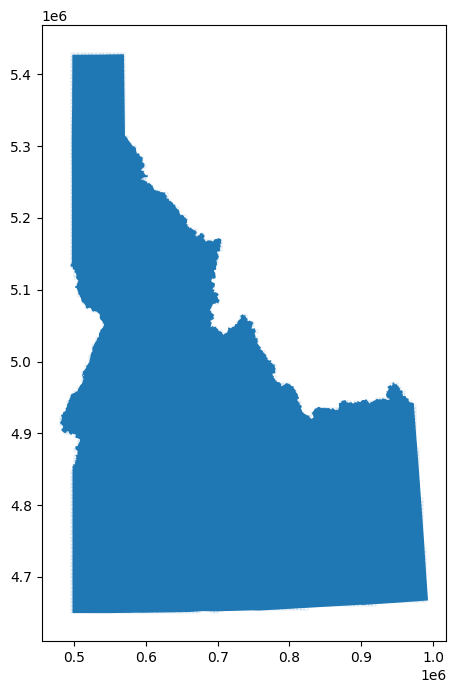

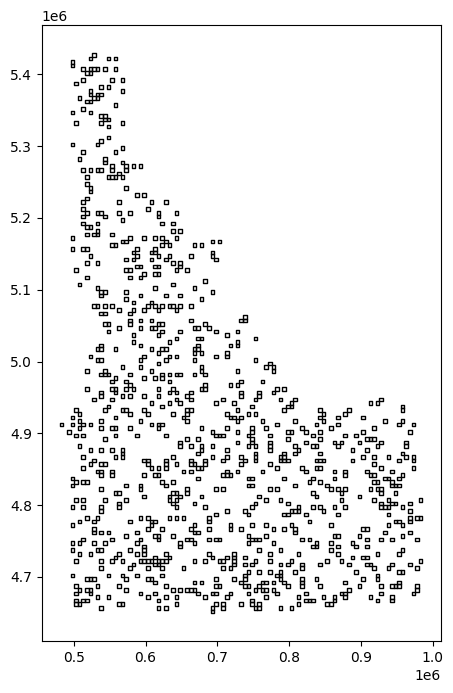

In [123]:
# grid QC
print('Are the cell IDs all unique?: ' + str(grid["cell_id"].is_unique))
print(grid.crs)
print('There are ' + str(len(grid)) + ' cells in the grid.')
cell = grid.geometry.iloc[0]

# check cell dimensions
# print(cell.bounds)
minx, miny, maxx, maxy = cell.bounds
print('The x cell dimensions are '+ str(maxx - minx) + ' meters.')
print('The y cell dimensions are ' + str(maxy - miny) + ' meters.')

# state-wide grid is too fine to see
ax = aoi.plot(figsize=(8, 8))
grid.boundary.plot(ax=ax, linewidth=0.1)

# plot a random subset of cells
grid.sample(1000).plot(
    facecolor="none",
    edgecolor="black",
    figsize=(8, 8))

# print(grid.head())
# print(grid.columns)

# Part 4. sample data into grid

In [124]:
# load target - known producing gold mines
mines_gdf_processed_producer = gpd.read_file(
    '/Users/adbyerly/prospectivity_model/data/processed/mines_gdf_processed_producer.geojson')

print(mines_gdf_processed_producer.head())
print(mines_gdf_processed_producer.crs)
target_crs='EPSG:32611'

    IGSID                                           NameList  \
0  BA0006                                  North Hornet Mine   
1  BA0015  Cuddy Mine, Freeze Prospect, Cuddy Mountain Mi...   
2  BA0017  Keystone, Galena, Lead Zone Mine, Salena, Gale...   
3  BA0018         Edna May Prospect, Snowslide, Mundee Mines   
4  BA0032                    Railroad Mine, Held Mine, Heald   

                                          CommodityL  \
0  uranium, gold, tantalum, niobium, abrasives, c...   
1                         silver, gold, copper, iron   
2                   lead, silver, zinc, copper, gold   
3                   silver, gold, copper, zinc, lead   
4                      gold, silver, bismuth, copper   

                                          CompanyLis    NAD27lon   NAD27lat  \
0                                                NaN -116.638173  44.890766   
1               Aries Resources, Cuddy Mountain Gold -116.732617  44.810767   
2  Lead Zone Mining, Mundee Mines, Anglo-

In [125]:
# join mine locations with grid; resulting dataframe will be mine data with cell id added as a column
mine_cells = gpd.sjoin(mines_gdf_processed_producer, 
                       grid[['cell_id', 'geometry']],
                       predicate = 'within', 
                       how = 'left')

grid['gold'] = (grid['cell_id'].isin(mine_cells['cell_id']).astype(int))
print(grid["gold"].value_counts())
# print(mine_cells.head())
print(grid.head())

gold
0    7917
1     789
Name: count, dtype: int64
                                              geometry  cell_id  gold
52   POLYGON ((485643.93 4909552.881, 485643.93 491...        0     0
53   POLYGON ((485643.93 4914552.881, 485643.93 491...        1     0
54   POLYGON ((485643.93 4919552.881, 485643.93 492...        2     0
206  POLYGON ((490643.93 4899552.881, 490643.93 490...        3     0
207  POLYGON ((490643.93 4904552.881, 490643.93 490...        4     0


<Axes: >

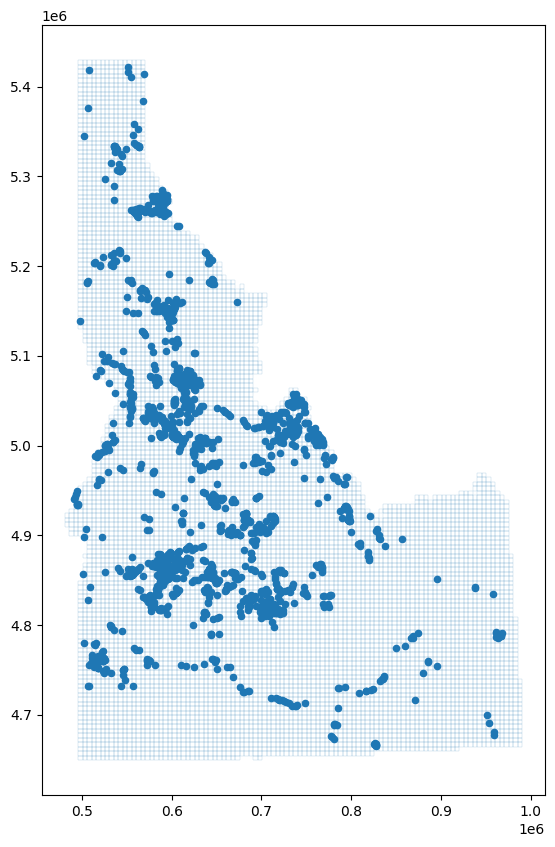

In [126]:
ax = grid.boundary.plot(figsize=(10,10), linewidth=0.1)

mines_gdf_processed_producer.plot(ax=ax,markersize=20)

In [127]:
# assign cell IDs to NGDB NAA geochemical data
ngdb_naa_pathfinders = gpd.read_file(data_path + "/NGDB/ngdb_naa_pathfinders.geojson")
# print(ngdb_naa_pathfinders.head())
# print(ngdb_naa_pathfinders.crs)

ngdb_naa_pathfinders_cells = gpd.sjoin(ngdb_naa_pathfinders,
                     grid[['cell_id', 'geometry']],
                     predicate = 'within',
                     how = 'left')

print(ngdb_naa_pathfinders_cells.head())

    lab_id  auppb_na  coppm_na  sbppm_na  asppm_na  znppm_na  \
0  C176401       NaN     0.350    0.0629     0.527      10.8   
1  C176402       NaN    17.400    0.0271     0.246      72.0   
2  C176403       0.1    17.200    0.0464     0.642      92.8   
3  C176411       0.1     0.476    0.0677     0.227      36.3   
4  C176412       NaN     8.610    0.0733     0.267      84.4   

                         geometry  index_right  cell_id  
0   POINT (549643.39 4966000.348)       2091.0   1469.0  
1  POINT (549754.439 4965846.793)       2091.0   1469.0  
2  POINT (549754.439 4965846.793)       2091.0   1469.0  
3  POINT (588531.423 4959290.827)       3337.0   2641.0  
4  POINT (583978.986 4959476.391)       3181.0   2511.0  


In [128]:
# aggregate NGDB NAA geochemical data by cell
# start by creating dataframe with aggregate max values for each pathfinder element

ngdb_naa_pathfinders_grid = (ngdb_naa_pathfinders_cells.groupby('cell_id').agg({
        'auppb_na' : 'max',
        'coppm_na' : 'max',
        'sbppm_na' : 'max',
        'asppm_na' : 'max',
        'znppm_na' : 'max',
        'lab_id' : 'count'}).rename(columns={'lab_id' : 'sample_count'}))

print(ngdb_naa_pathfinders_grid.head())

         auppb_na  coppm_na  sbppm_na  asppm_na  znppm_na  sample_count
cell_id                                                                
70.0          NaN     42.80       NaN       NaN     116.0             1
81.0          NaN     30.00      1.99       NaN     225.0             1
111.0         4.0      1.54      0.07       0.5      23.4             2
137.0         3.0      0.55      0.42       4.4      59.8             2
141.0         4.0      0.34      0.25       2.1      61.2             2


In [129]:
#  join of geochemical data with grid

grid = grid.merge(ngdb_naa_pathfinders_grid, on = 'cell_id', how = 'left')

                                            geometry  cell_id  gold  auppb_na  \
0  POLYGON ((485643.93 4909552.881, 485643.93 491...        0     0       NaN   
1  POLYGON ((485643.93 4914552.881, 485643.93 491...        1     0       NaN   
2  POLYGON ((485643.93 4919552.881, 485643.93 492...        2     0       NaN   
3  POLYGON ((490643.93 4899552.881, 490643.93 490...        3     0       NaN   
4  POLYGON ((490643.93 4904552.881, 490643.93 490...        4     0       NaN   

   coppm_na  sbppm_na  asppm_na  znppm_na  sample_count  
0       NaN       NaN       NaN       NaN           NaN  
1       NaN       NaN       NaN       NaN           NaN  
2       NaN       NaN       NaN       NaN           NaN  
3       NaN       NaN       NaN       NaN           NaN  
4       NaN       NaN       NaN       NaN           NaN  


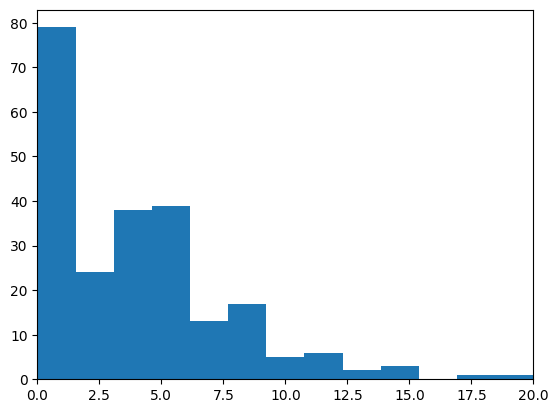

In [130]:
# check gold data to make sure geochemical sampling and aggregation workflow succeeded
print(grid.head())
au = grid['auppb_na']
plt.hist(au, range = (0,20), bins='auto')
plt.xlim(0, 20)
plt.show()

# Part 5. export data

In [131]:
# save NGDB NAA data
grid.to_file(data_path + 'grid.geojson', driver = 'GeoJSON')